In [7]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        os.path.join(dirname, filename)

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [8]:
import warnings
warnings.filterwarnings('ignore')

In [9]:
from keras.layers import Input,Lambda,Dense,Flatten,Conv2D
from keras.models import Model
from keras.preprocessing import image
from keras.applications.vgg16 import VGG16
from keras.preprocessing.image import ImageDataGenerator,load_img
from keras.models import Sequential
from glob import glob
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from PIL import Image
import os
import random

In [10]:
df = pd.read_csv(r"../input/cassava-leaf-disease-classification/train.csv")
df.head()

,image_id,label
0,1000015157.jpg,0
1,1000201771.jpg,3
2,100042118.jpg,1
3,1000723321.jpg,1
4,1000812911.jpg,3


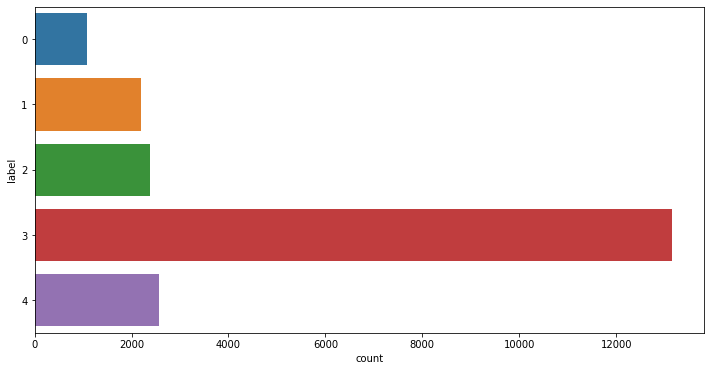

In [11]:
plt.figure(figsize=(12,6))
sns.countplot(y='label',data=df)
plt.show()

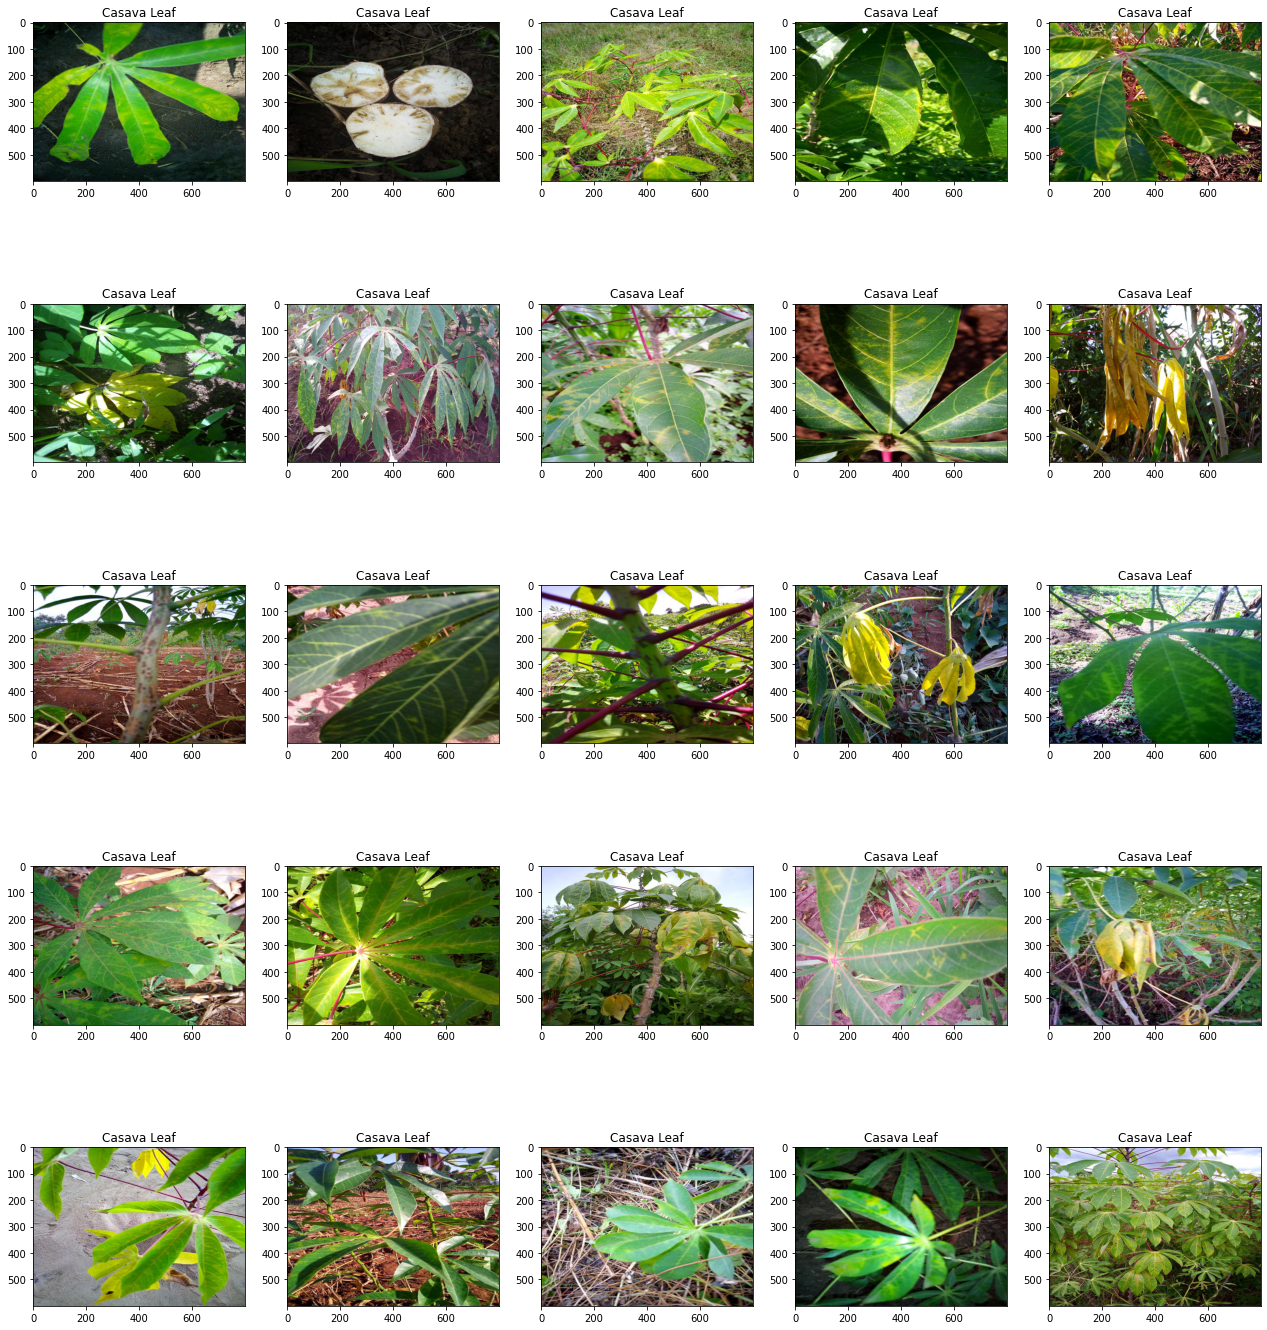

In [12]:
plt.figure(figsize=(22,25))
path = '../input/cassava-leaf-disease-classification/train_images/'
temp = df[df['label']==1]['image_id']  #all the images of dogs will be stored in temp
start = random.randint(0,len(temp))  #this generates a random number between 0 and len(temp)
files = temp[start:start+25]         #in files we store the first 25 continuous images between the random number generated 
                                     #since temp is basically images of dogs from step 2
for index,file in enumerate(files):
  plt.subplot(5,5,index+1)
  img = load_img(path+file)
  img = np.array(img)
  plt.imshow(img)
  plt.imshow(img)
  plt.title('Casava Leaf')
  plt.axis()

In [13]:
WORK_DIR = '../input/cassava-leaf-disease-classification'

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import models, layers
from tensorflow.keras.preprocessing import image
from tensorflow.keras.optimizers import Adam
import cv2

Total number of images in train_images folder

In [15]:
import os
print(len(os.listdir('../input/cassava-leaf-disease-classification/train_images')))

21397


In [16]:
df.label = df.label.astype('str')

train_datagen = ImageDataGenerator(validation_split = 0.2,
                                     preprocessing_function = None,
                                     rotation_range = 45,
                                     zoom_range = 0.2,
                                     horizontal_flip = True,
                                     vertical_flip = True,
                                     fill_mode = 'nearest',
                                     shear_range = 0.1,
                                     height_shift_range = 0.1,
                                     width_shift_range = 0.1)

train_generator = train_datagen.flow_from_dataframe(df,
                         directory = os.path.join(WORK_DIR, "train_images"),
                         subset = "training",
                         x_col = "image_id",
                         y_col = "label",
                         target_size = (224,224),
                         batch_size = 32,
                         class_mode = "categorical")


validation_datagen = ImageDataGenerator(validation_split = 0.2)

validation_generator = validation_datagen.flow_from_dataframe(df,
                         directory = os.path.join(WORK_DIR, "train_images"),
                         subset = "validation",
                         x_col = "image_id",
                         y_col = "label",
                         target_size = (224, 224),
                         batch_size = 32,
                         class_mode = "categorical")

Found 17118 validated image filenames belonging to 5 classes.
Found 4279 validated image filenames belonging to 5 classes.


In [17]:
vgg = VGG16(input_shape=[224,224,3],weights='imagenet',include_top=False)

2022-02-19 04:58:50.689407: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-02-19 04:58:50.811665: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-02-19 04:58:50.812414: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-02-19 04:58:50.813600: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compil

58900480/58889256 [==============================] - 0s 0us/step


In [18]:
for layer in vgg.layers:
    layer.trainable = False

In [19]:
x = Flatten()(vgg.output)

In [20]:
vgg_output = Dense(5,activation='softmax')(x)
#This is the last layer cnsisting of the various classes we are replacing the include_top = False layer with this one

In [21]:
len(df)

21397

In [22]:
model = Model(inputs=vgg.input, outputs=vgg_output)

In [23]:
model.summary()

Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 224, 224, 3)]     0         
_________________________________________________________________
block1_conv1 (Conv2D)        (None, 224, 224, 64)      1792      
_________________________________________________________________
block1_conv2 (Conv2D)        (None, 224, 224, 64)      36928     
_________________________________________________________________
block1_pool (MaxPooling2D)   (None, 112, 112, 64)      0         
_________________________________________________________________
block2_conv1 (Conv2D)        (None, 112, 112, 128)     73856     
_________________________________________________________________
block2_conv2 (Conv2D)        (None, 112, 112, 128)     147584    
_________________________________________________________________
block2_pool (MaxPooling2D)   (None, 56, 56, 128)       0     

In [28]:
model.compile(optimizer=Adam(lr=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [29]:
history = model.fit(
  train_generator,
  validation_data=validation_generator,
  epochs=10,
  steps_per_epoch=len(train_generator),
  validation_steps=len(validation_generator)
)

Epoch 1/10
535/535 [==============================] - 339s 633ms/step - loss: 17.5857 - accuracy: 0.6521 - val_loss: 19.7555 - val_accuracy: 0.6123
Epoch 2/10
535/535 [==============================] - 340s 635ms/step - loss: 15.4095 - accuracy: 0.6618 - val_loss: 17.5418 - val_accuracy: 0.6422
Epoch 3/10
535/535 [==============================] - 342s 639ms/step - loss: 14.2259 - accuracy: 0.6632 - val_loss: 17.7725 - val_accuracy: 0.6072
Epoch 4/10
535/535 [==============================] - 340s 635ms/step - loss: 13.6917 - accuracy: 0.6674 - val_loss: 15.6629 - val_accuracy: 0.6354
Epoch 5/10
535/535 [==============================] - 342s 639ms/step - loss: 12.8251 - accuracy: 0.6661 - val_loss: 15.3453 - val_accuracy: 0.6490
Epoch 6/10
535/535 [==============================] - 341s 638ms/step - loss: 12.5947 - accuracy: 0.6657 - val_loss: 15.1679 - val_accuracy: 0.6135
Epoch 7/10
535/535 [==============================] - 340s 636ms/step - loss: 11.6741 - accuracy: 0.6709 - val_l

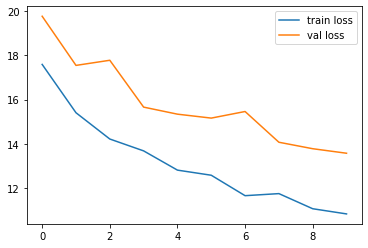

In [30]:
#loss
plt.plot(history.history['loss'],label='train loss')
plt.plot(history.history['val_loss'],label = 'val loss')
plt.legend()
plt.show()

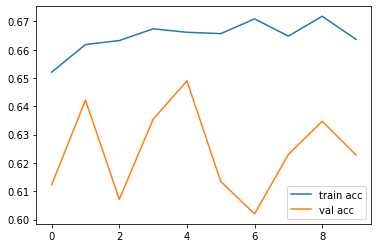

In [31]:
#accuracy
plt.plot(history.history['accuracy'],label='train acc')
plt.plot(history.history['val_accuracy'],label='val acc')
plt.legend()
plt.show()

In [35]:
ss = pd.read_csv(os.path.join(WORK_DIR, "sample_submission.csv"))
ss

,image_id,label
0,2216849948.jpg,4


In [39]:
preds = []

for image_id in ss.image_id:
    image = Image.open(os.path.join(WORK_DIR,  "test_images", image_id))
    image = image.resize((224,224))
    image = np.expand_dims(image, axis = 0)
    preds.append(np.argmax(model.predict(image)))

ss['label'] = preds
ss

,image_id,label
0,2216849948.jpg,4


In [40]:
ss.to_csv('submission.csv', index = False)


In [41]:
from keras.models import Model
model.save('cassava.h5')